#### Try removing E-to-B leakage by first constructing E and B modes without Galactic mask and then applying the mask to B mode

In [1]:
import numpy as np, healpy as hp, tqdm, cmb, local, warnings
from matplotlib.pyplot import *
from cmblensplus import curvedsky as cs
warnings.filterwarnings("ignore")

In [2]:
def compute_clfg(pobj,rlz,M,lmax,NSIDE=64,method=0):
    QU = hp.read_map(pobj.ffgs[rlz],field=(1,2))
    QU = hp.ud_grade( QU, NSIDE )
    if method == 0:
        Elm, Blm = cs.utils.hp_map2alm_spin(lmax,lmax,2,QU[0],QU[1])
        QB, UB = cs.utils.hp_alm2map_spin(NSIDE,2,0*Elm,Blm)
        Elm, Blm = cs.utils.hp_map2alm_spin(lmax,lmax,2,M*QB,M*UB)
    if method == 1:
        Elm, Blm = cs.utils.hp_map2alm_spin(lmax,lmax,2,M*QU[0],M*QU[1])
    return cs.utils.alm2cl(Blm)

In [3]:
# define parameters
lmax  = 190     # maximum multipole of alm to be generated
NSIDE = 128
l = np.linspace(0,lmax,lmax+1)
fac = l*(l+1)/2/np.pi
wl = hp.sphtfunc.pixwin(NSIDE,lmax=lmax)
bl = cmb.beam(80.,lmax)

### Read galaxy survey mask

In [4]:
M = hp.ud_grade(hp.read_map('../data/lensing/FG_mask.fits'),NSIDE)
W = cs.utils.apodize(M, 1.)
W2 = np.mean(W**2)
print(W2)

 converting RING -> NESTED
 compute distance
 converting NESTED - > RING
 compute apodized window
0.4625447088127248


In [5]:
pobj = local.analysis()

In [6]:
simn = 10
BB = np.zeros((2,simn,lmax+1))
for rlz in tqdm.tqdm(range(1,simn+1)):
    BB[0,rlz-1] = compute_clfg(pobj,rlz,W,lmax,NSIDE=NSIDE)
    BB[1,rlz-1] = compute_clfg(pobj,rlz,W,lmax,NSIDE=NSIDE,method=1)
mBB = np.mean(BB,axis=1)

100%|██████████| 10/10 [00:00<00:00, 17.82it/s]


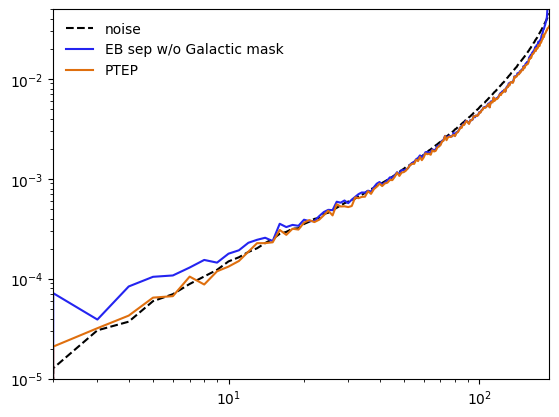

In [8]:
xlim(2,190)
ylim(1e-5,5e-2)
loglog(l,fac*pobj.clfg[:lmax+1]*cmb.Tcmb**2,label='noise',color='k',ls='--')
loglog(l,fac*mBB[0]/W2/wl**2*bl**2,label='EB sep w/o Galactic mask')
loglog(l,fac*mBB[1]/W2/wl**2*bl**2,label='PTEP')
legend()